In [3]:
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as TF
from torchvision import transforms
import timm
from PIL import Image

In [4]:
# Xception preprocessing: scale to [-1, 1]
MEAN = torch.tensor([0.5, 0.5, 0.5])
STD  = torch.tensor([0.5, 0.5, 0.5])

In [5]:
class Xception65Backbone(nn.Module):
    def __init__(self, pretrained=True, output_stride=16):
        super().__init__()
        
        # Consolidation: Pass output_stride directly to the constructor 
        # to avoid creating the model twice.
        self.backbone = timm.create_model(
            "xception65",
            pretrained=pretrained,
            features_only=True,
            out_indices=[0, 4],
            output_stride=output_stride, # Set this once here
        )

    def forward(self, x):
        feats = self.backbone(x)
        low_level_feat  = feats[0]   # (B, 128, H/4,  W/4)
        high_level_feat = feats[1]   # (B, 2048, H/16, W/16)
        return low_level_feat, high_level_feat

    def freeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_from(self, block_num=16):
        """Freeze everything before block_name, unfreeze the rest."""
        # Fixed Indentation below:
        freeze_active = True
        for name, param in self.backbone.named_parameters():
            if f'blocks.{block_num}' in name:
                freeze_active = False
            param.requires_grad = not freeze_active

In [6]:
class ConvBnRelu(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1,
                 dilation=1, bias=False, activation=True):
        padding = dilation if kernel == 3 else 0
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride,
                      padding=padding, dilation=dilation, bias=bias),
            nn.BatchNorm2d(out_ch),
        ]
        if activation:
            layers.append(nn.ReLU(inplace=True))
        super().__init__(*layers)

In [7]:
class ASPP(nn.Module):
    def __init__(self, in_channels=2048, out_channels=256, output_stride=16, img_size=384):
        super().__init__()
        
        # Scale rates to feature map size — rates should be < feature_map_size/2
        feat_size = img_size // output_stride   # 384//16 = 24
        
        if output_stride == 16:
            if feat_size >= 32:               # 512×512 and above
                rates = [6, 12, 18]
            elif feat_size >= 24:             # 384×384
                rates = [4, 8, 12]            # all fit within 24px feature map
            else:                             # 256×256 — feat_size=16
                rates = [3, 6, 9]             # rate=9 spans 19px, borderline ok
        else:  # output_stride == 8
            rates = [12, 24, 36]

        self.b1 = ConvBnRelu(in_channels, out_channels, kernel=1)
        self.b2 = ConvBnRelu(in_channels, out_channels, kernel=3, dilation=rates[0])
        self.b3 = ConvBnRelu(in_channels, out_channels, kernel=3, dilation=rates[1])
        self.b4 = ConvBnRelu(in_channels, out_channels, kernel=3, dilation=rates[2])

        self.global_avg = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvBnRelu(in_channels, out_channels, kernel=1),
        )

        self.proj = ConvBnRelu(out_channels * 5, out_channels, kernel=1)
        self.drop = nn.Dropout2d(0.1)

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        b1 = self.b1(x)
        b2 = self.b2(x)
        b3 = self.b3(x)
        b4 = self.b4(x)
        b5 = F.interpolate(self.global_avg(x), size=(h, w),
                           mode="bilinear", align_corners=False)
        x  = torch.cat([b1, b2, b3, b4, b5], dim=1)
        x  = self.proj(x)
        x  = self.drop(x)
        return x

In [28]:
class Decoder(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, low_level_channels=128):
        super().__init__()
        self.low_proj = ConvBnRelu(low_level_channels, 48, kernel=1)
        self.conv1 = ConvBnRelu(256 + 48, 256, kernel=3)
        self.conv2 = ConvBnRelu(256,      256, kernel=3)
        self.drop  = nn.Dropout2d(0.1)
        
        # Normalize features before classification head
        self.head_norm = nn.GroupNorm(32, 256)   # ← add this
        self.cls  = nn.Conv2d(256, num_classes, kernel_size=1)

        nn.init.kaiming_normal_(self.cls.weight, nonlinearity="relu")
        nn.init.zeros_(self.cls.bias)

    def forward(self, aspp_out, low_level_feat, output_size):
        low  = self.low_proj(low_level_feat)
        aspp = F.interpolate(aspp_out, size=low.shape[2:],
                             mode="bilinear", align_corners=False)
        x = torch.cat([aspp, low], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.drop(x)
        x = F.interpolate(x, size=output_size,
                          mode="bilinear", align_corners=False)
        x = self.head_norm(x)   # ← normalize before cls layer
        x = self.cls(x)
        return x

In [29]:
class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, output_stride=OUTPUT_STRIDE,
                 pretrained_backbone=True, img_size=IMAGE_SIZE):
        super().__init__()
        self.backbone = Xception65Backbone(pretrained=pretrained_backbone,
                                           output_stride=output_stride)
        self.aspp = ASPP(in_channels=2048, output_stride=output_stride,
                         img_size=img_size)                          # ← pass it
        self.decoder = Decoder(num_classes=num_classes, low_level_channels=128)

    def forward(self, x):
        output_size = (x.shape[2], x.shape[3])
        low_feat, high_feat = self.backbone(x)
        aspp_out = self.aspp(high_feat)
        logits   = self.decoder(aspp_out, low_feat, output_size)
        return logits           

In [30]:
torch.backends.cudnn.benchmark = True

In [31]:
NUM_CLASSES = 2
OUTPUT_STRIDE = 16
IMAGESIZE = 256

✅ Model loaded and set to evaluation mode.


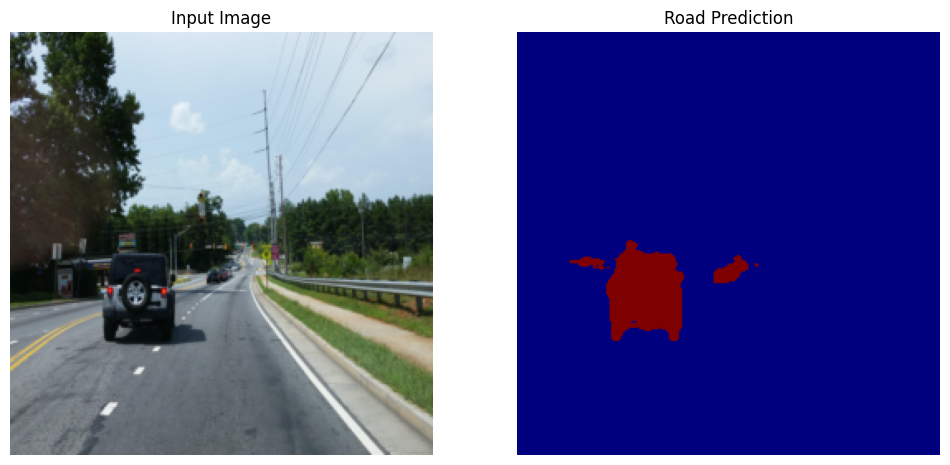

In [132]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Configuration (Match your training script)
NUM_CLASSES   = 2
IMAGE_SIZE    = 256
OUTPUT_STRIDE = 16
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH    = "car_model_param_final.pth"

# 2. Re-initialize Architecture
# Ensure the classes/functions from your previous cell (DeepLabV3Plus, etc.) are defined
segment_model = DeepLabV3Plus(
    num_classes=NUM_CLASSES, 
    output_stride=OUTPUT_STRIDE, 
    pretrained_backbone=False # Set to False since we are loading our own weights
).to(DEVICE)

# 3. Load Params with Compilation Handling
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

# Remove '_orig_mod.' prefix added by torch.compile
new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

segment_model.load_state_dict(new_state_dict)
segment_model.eval()
print("✅ Model loaded and set to evaluation mode.")

# 4. Inference Function
def segment_road(image_path, threshold=0.5):
    # Load and Resize
    img_org = Image.open(image_path).convert("RGB")
    img_resized = img_org.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    
    # Preprocessing (Xception specific: scale to [-1, 1])
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = (img_array - 0.5) / 0.5  # MEAN=0.5, STD=0.5
    
    # To Tensor: [H, W, C] -> [1, C, H, W]
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = segment_model(img_tensor)
        # Apply Softmax to get probabilities
        probs = torch.softmax(output, dim=1)
        # Get the mask for the road class (assuming index 1 is road)
        mask = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
        
    return img_resized, mask

# 5. Run and Visualize
img_path = "road_car_bg.jpg" # Update this!
original, mask = segment_road(img_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Input Image")

plt.imshow(original)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Road Prediction")
plt.imshow(mask, cmap="jet")
plt.axis("off")

plt.show()

✅ Model loaded and set to evaluation mode.


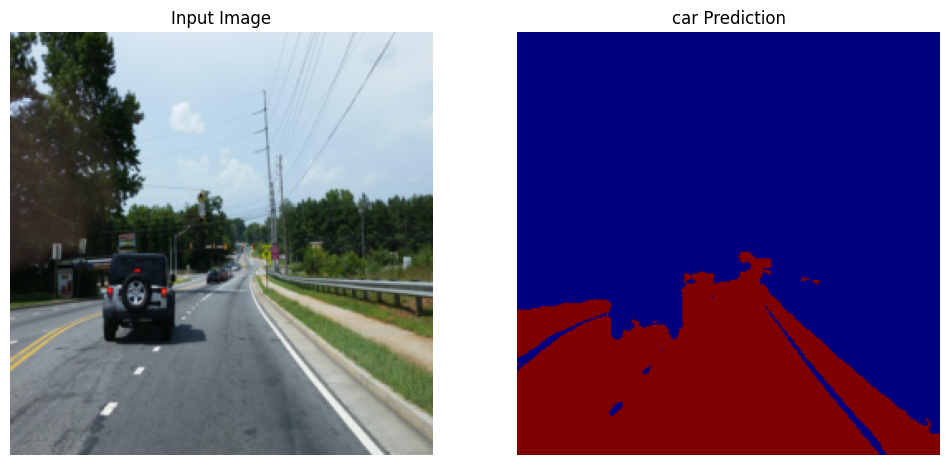

In [133]:
MODEL_PATH    = "road_model_param.pth"

# 2. Re-initialize Architecture
# Ensure the classes/functions from your previous cell (DeepLabV3Plus, etc.) are defined
# model = DeepLabV3Plus(
#     num_classes=NUM_CLASSES, 
#     output_stride=OUTPUT_STRIDE, 
#     pretrained_backbone=False # Set to False since we are loading our own weights
# ).to(DEVICE)

# 3. Load Params with Compilation Handling
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

# Remove '_orig_mod.' prefix added by torch.compile
new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

segment_model.load_state_dict(new_state_dict)
segment_model.eval()
print("✅ Model loaded and set to evaluation mode.")

# 4. Inference Function
def segment_road(image_path, threshold=0.5):
    # Load and Resize
    img_org = Image.open(image_path).convert("RGB")
    img_resized = img_org.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    
    # Preprocessing (Xception specific: scale to [-1, 1])
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = (img_array - 0.5) / 0.5  # MEAN=0.5, STD=0.5
    
    # To Tensor: [H, W, C] -> [1, C, H, W]
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = segment_model(img_tensor)
        # Apply Softmax to get probabilities
        probs = torch.softmax(output, dim=1)
        # Get the mask for the road class (assuming index 1 is road)
        mask1 = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
        
    return img_resized, mask1

# 5. Run and Visualize
img_path = "road_car_bg.jpg" # Update this!
original, mask1 = segment_road(img_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(original)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("car Prediction")
plt.imshow(mask1, cmap="jet")
plt.axis("off")

plt.show()

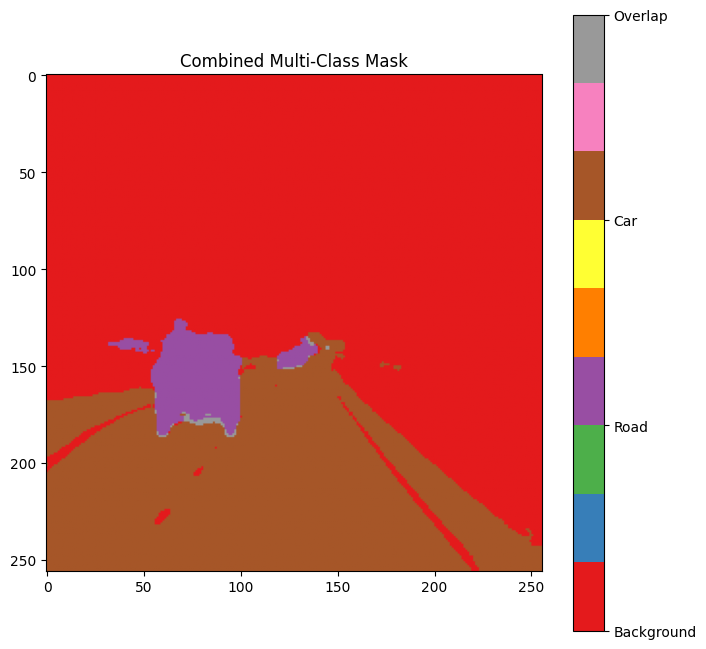

In [98]:
# 1. Ensure you have two distinct arrays from your two models
# mask_road = model_road_output
# mask_car  = model_car_output

# 2. Create an empty canvas
combined_mask = np.zeros_like(mask, dtype=np.uint8)

# 3. Assign IDs carefully
# Pixels where Road model predicted 1 -> stay 1
combined_mask[mask == 1] = 1

# Pixels where Car model predicted 1 -> become 2
# FIX: Use the OTHER mask variable here
combined_mask[mask1 == 1] = 2 

# 4. Handle Overlaps (Where a pixel is predicted as both)
# FIX: Use both distinct variables
overlap = np.logical_and(mask == 1, mask1 == 1)
combined_mask[overlap] = 3 

# 5. Visualize
plt.figure(figsize=(8, 8))
# 'Set1' or 'tab10' are good for showing distinct integer classes
plt.imshow(combined_mask, cmap='Set1') 
cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Background', 'Road', 'Car', 'Overlap'])
plt.title("Combined Multi-Class Mask")
plt.show()

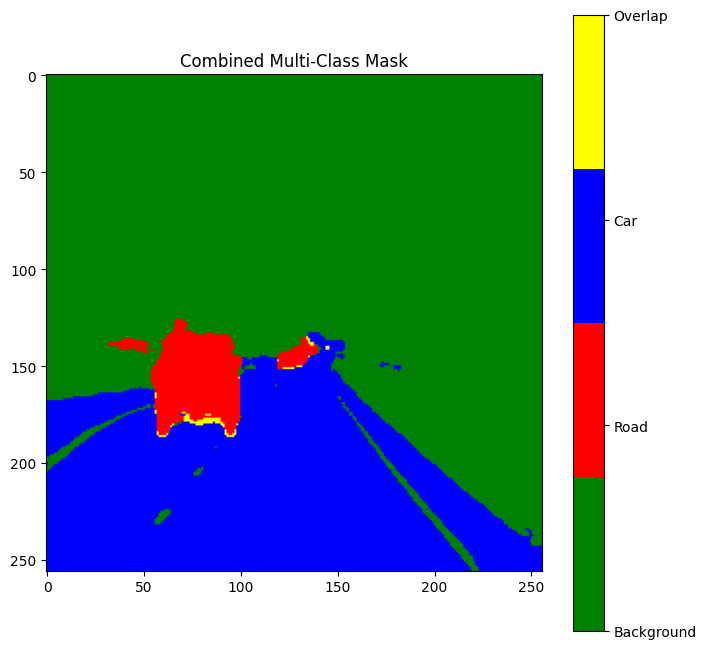

In [103]:
from matplotlib.colors import ListedColormap

# Define colors:
# 0 = Background (Green)
# 1 = Road
# 2 = Car
# 3 = Overlap
colors = [
    "green",   # Background
    "red",     # Road
    "blue",    # Car
    "yellow"   # Overlap
]

cmap = ListedColormap(colors)

plt.figure(figsize=(8, 8))
plt.imshow(combined_mask, cmap=cmap)

cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Background', 'Road', 'Car', 'Overlap'])

plt.title("Combined Multi-Class Mask")
plt.show()

In [106]:
# ── Model ──────────────────────────────────────────────────────────────────────
class EfficientNetV2MultiLabel(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, pretrained=True):
        super().__init__()
        # Using 's' version for speed and 4GB VRAM
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s', 
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        
        # This line automatically finds if it's 1280 or something else
        num_in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def unfreeze_top_layers(self, num_layers=20):
        """Phase 2: selectively unfreeze top N backbone param groups."""
        all_params = list(self.backbone.named_parameters())
        print(f"Unfreezing top {num_layers} of {len(all_params)} backbone params")
        for _, param in all_params[-num_layers:]:
            param.requires_grad = True

In [156]:
router_model = EfficientNetV2MultiLabel(num_classes=2)

In [157]:
MODEL_PATH = "road_car_router.pth"

In [158]:
# 3. Load Params with Compilation Handling
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

# Remove '_orig_mod.' prefix added by torch.compile
new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

In [159]:
router_model.load_state_dict(new_state_dict)
print("✅ Model loaded and set to evaluation mode.")

✅ Model loaded and set to evaluation mode.


In [160]:
from PIL import Image
import torchvision.transforms as transforms
import torch

image_path = "check_road_only.jpg"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

image = Image.open(image_path).convert("RGB")
image = transform(image)

model.eval()

with torch.no_grad():
    output = router_model(image.unsqueeze(0))

In [161]:
print(output)

tensor([[3.8006, 4.7846]])


In [162]:
import torch.nn.functional as F

prob_dis = F.softmax(output, dim=1)
prob_class_dis = prob_dis[0]
print(prob_dis[0])

tensor([0.2721, 0.7279])


In [163]:
def segment_road_complete(image_path = image_path, model = segment_model, MODEL_PATH = "road_model_param.pth"):

    # 3. Load Params with Compilation Handling
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
    
    # Remove '_orig_mod.' prefix added by torch.compile
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    
    model.load_state_dict(new_state_dict)
    model.eval()

    # Load and Resize
    img_org = Image.open(image_path).convert("RGB")
    img_resized = img_org.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    
    # Preprocessing (Xception specific: scale to [-1, 1])
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = (img_array - 0.5) / 0.5  # MEAN=0.5, STD=0.5
    
    # To Tensor: [H, W, C] -> [1, C, H, W]
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(img_tensor)
        # Apply Softmax to get probabilities
        probs = torch.softmax(output, dim=1)
        # Get the mask for the road class (assuming index 1 is road)
        mask = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy() 

    return  mask
    

In [164]:
def segment_car_complete(image_path = image_path, model = segment_model, MODEL_PATH = "car_model_param_final.pth"):

    # 3. Load Params with Compilation Handling
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
    
    # Remove '_orig_mod.' prefix added by torch.compile
    new_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    
    model.load_state_dict(new_state_dict)
    model.eval()

    # Load and Resize
    img_org = Image.open(image_path).convert("RGB")
    img_resized = img_org.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    
    # Preprocessing (Xception specific: scale to [-1, 1])
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = (img_array - 0.5) / 0.5  # MEAN=0.5, STD=0.5
    
    # To Tensor: [H, W, C] -> [1, C, H, W]
    img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(img_tensor)
        # Apply Softmax to get probabilities
        probs = torch.softmax(output, dim=1)
        # Get the mask for the road class (assuming index 1 is road)
        mask = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
    
    return mask

In [166]:
total_img_class = 0

class_map = {
    "road":0,
    "car":0
}

if(prob_class_dis[0] > 0.05):
    total_img_class +=1
    class_map["road"] = 1
    road_mask = segment_road_complete()


if(prob_class_dis[1] > 0.05):
    total_img_class +=1
    class_map["car"] = 1
    car_mask = segment_car_complete()



combined_mask = np.zeros_like(car_mask, dtype=np.uint8)
    
if(total_img_class == 1):

    if(road == 1):
        combined_mask[road_mask == 1] = 1
    else:
        combined_mask[car_mask == 1] = 2
        
elif(total_img_class > 1):

    combined_mask[road_mask == 1] = 1
    combined_mask[car_mask == 1] = 2
    overlap = np.logical_and(road_mask == 1, car_mask == 1)
    combined_mask[overlap] = 3

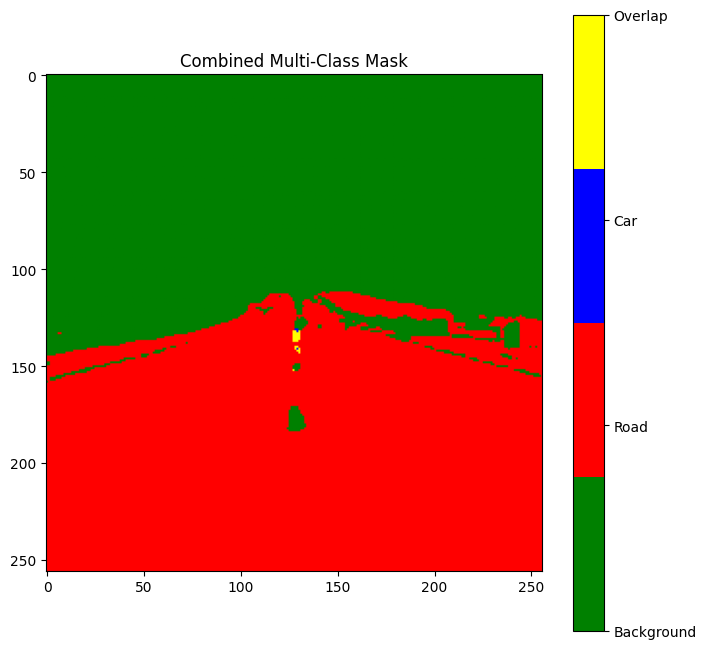

In [167]:
from matplotlib.colors import ListedColormap

# Define colors:
# 0 = Background (Green)
# 1 = Road
# 2 = Car
# 3 = Overlap
colors = [
    "green",   # Background
    "red",     # Road
    "blue",    # Car
    "yellow"   # Overlap
]

cmap = ListedColormap(colors)

plt.figure(figsize=(8, 8))
plt.imshow(combined_mask, cmap=cmap)

cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Background', 'Road', 'Car', 'Overlap'])

plt.title("Combined Multi-Class Mask")
plt.show()